# ROUND5 Commodity Alpha Exploration

This notebook is a first-pass research workbench for the `ROUND5_data` commodity universe. It focuses on alpha discovery rather than final production strategy code:

- load and normalize price/order-book snapshots plus public trades
- map products into natural families such as `PEBBLES`, `SNACKPACK`, `MICROCHIP`, etc.
- build microstructure and relative-value features
- test forward-return predictiveness with a train/validation split
- scan within-family pairs for mean-reverting spreads
- inspect trade-print markouts around the tape

The default split treats days 2-3 as research/training data and day 4 as validation. That keeps the notebook honest enough to avoid immediately falling in love with day-specific noise.

In [2]:
from pathlib import Path
from itertools import combinations
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = Path("ROUND5_data")
PRICE_FILES = sorted(DATA_DIR.glob("prices_round_5_day_*.csv"))
TRADE_FILES = sorted(DATA_DIR.glob("trades_round_5_day_*.csv"))

TRAIN_DAYS = [2, 3]
VALID_DAYS = [4]
HORIZONS = [1, 5, 20, 100]

PRICE_FILES, TRADE_FILES

([PosixPath('ROUND5_data/prices_round_5_day_2.csv'),
  PosixPath('ROUND5_data/prices_round_5_day_3.csv'),
  PosixPath('ROUND5_data/prices_round_5_day_4.csv')],
 [PosixPath('ROUND5_data/trades_round_5_day_2.csv'),
  PosixPath('ROUND5_data/trades_round_5_day_3.csv'),
  PosixPath('ROUND5_data/trades_round_5_day_4.csv')])

## Load Data

The CSVs are semicolon-delimited. Trade files do not contain a `day` column, so the loader recovers it from the filename and adds it explicitly.

In [3]:
def day_from_name(path: Path) -> int:
    match = re.search(r"day_(\d+)", path.name)
    if not match:
        raise ValueError(f"Could not parse day from {path}")
    return int(match.group(1))


def load_prices(files=PRICE_FILES) -> pd.DataFrame:
    frames = []
    for path in files:
        frame = pd.read_csv(path, sep=";")
        frame["source_file"] = path.name
        frames.append(frame)
    out = pd.concat(frames, ignore_index=True)
    out = out.sort_values(["day", "timestamp", "product"]).reset_index(drop=True)
    return out


def load_trades(files=TRADE_FILES) -> pd.DataFrame:
    frames = []
    for path in files:
        frame = pd.read_csv(path, sep=";")
        frame["day"] = day_from_name(path)
        frame["source_file"] = path.name
        frames.append(frame)
    out = pd.concat(frames, ignore_index=True)
    out = out.rename(columns={"symbol": "product"})
    out = out.sort_values(["day", "timestamp", "product"]).reset_index(drop=True)
    return out

prices_raw = load_prices()
trades_raw = load_trades()

print(f"prices: {prices_raw.shape[0]:,} rows x {prices_raw.shape[1]:,} columns")
print(f"trades: {trades_raw.shape[0]:,} rows x {trades_raw.shape[1]:,} columns")
print(f"products: {prices_raw['product'].nunique()}")
display(prices_raw.head())
display(trades_raw.head())

prices: 1,500,000 rows x 18 columns
trades: 35,385 rows x 9 columns
products: 50


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,source_file
0,2,0,GALAXY_SOUNDS_BLACK_HOLES,9994,22,"9,992.0000",26.0000,NaN,NaN,10006,22,"10,008.0000",26.0000,NaN,NaN,"10,000.0000",0.0000,prices_round_5_day_2.csv
1,2,0,GALAXY_SOUNDS_DARK_MATTER,9994,22,"9,992.0000",26.0000,NaN,NaN,10006,22,"10,008.0000",26.0000,NaN,NaN,"10,000.0000",0.0000,prices_round_5_day_2.csv
2,2,0,GALAXY_SOUNDS_PLANETARY_RINGS,9994,22,"9,992.0000",26.0000,NaN,NaN,10006,22,"10,008.0000",26.0000,NaN,NaN,"10,000.0000",0.0000,prices_round_5_day_2.csv
3,2,0,GALAXY_SOUNDS_SOLAR_FLAMES,9994,22,"9,992.0000",26.0000,NaN,NaN,10006,22,"10,008.0000",26.0000,NaN,NaN,"10,000.0000",0.0000,prices_round_5_day_2.csv
4,2,0,GALAXY_SOUNDS_SOLAR_WINDS,9994,22,"9,992.0000",26.0000,NaN,NaN,10006,22,"10,008.0000",26.0000,NaN,NaN,"10,000.0000",0.0000,prices_round_5_day_2.csv


,timestamp,buyer,seller,product,currency,price,quantity,day,source_file
0,1700,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,"9,969.0000",4,2,trades_round_5_day_2.csv
1,1700,NaN,NaN,GALAXY_SOUNDS_DARK_MATTER,XIRECS,"9,977.0000",4,2,trades_round_5_day_2.csv
2,1700,NaN,NaN,GALAXY_SOUNDS_PLANETARY_RINGS,XIRECS,"9,957.0000",4,2,trades_round_5_day_2.csv
3,1700,NaN,NaN,GALAXY_SOUNDS_SOLAR_FLAMES,XIRECS,"9,976.0000",4,2,trades_round_5_day_2.csv
4,1700,NaN,NaN,GALAXY_SOUNDS_SOLAR_WINDS,XIRECS,"10,084.0000",4,2,trades_round_5_day_2.csv


## Feature Engineering

The feature set starts intentionally simple:

- spread and depth from the top 3 book levels
- level-1 and level-3 order-book imbalance
- microprice edge versus mid
- short-term returns and future returns
- trade intensity and trade price edge versus mid
- within-family relative-value z-scores

In [4]:
FAMILY_PREFIXES = [
    "GALAXY_SOUNDS",
    "OXYGEN_SHAKE",
    "SLEEP_POD",
    "SNACKPACK",
    "TRANSLATOR",
    "UV_VISOR",
    "MICROCHIP",
    "PEBBLES",
    "PANEL",
    "ROBOT",
]


def infer_family(product: str) -> str:
    for prefix in sorted(FAMILY_PREFIXES, key=len, reverse=True):
        if product == prefix or product.startswith(prefix + "_"):
            return prefix
    return product.rsplit("_", 1)[0]


def add_price_features(prices: pd.DataFrame, trades: pd.DataFrame) -> pd.DataFrame:
    df = prices.copy()
    df["family"] = df["product"].map(infer_family)
    df["global_time"] = df["day"] * 1_000_000 + df["timestamp"]

    price_cols = [c for c in df.columns if "price" in c and c not in ["product"]]
    volume_cols = [c for c in df.columns if "volume" in c]
    df[price_cols + volume_cols] = df[price_cols + volume_cols].apply(pd.to_numeric, errors="coerce")

    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    df["spread_bps"] = df["spread"] / df["mid_price"] * 1e4
    df["depth_1"] = df["bid_volume_1"].fillna(0) + df["ask_volume_1"].fillna(0)
    df["depth_3"] = sum(df[f"bid_volume_{i}"].fillna(0) + df[f"ask_volume_{i}"].fillna(0) for i in [1, 2, 3])
    df["imbalance_1"] = (df["bid_volume_1"].fillna(0) - df["ask_volume_1"].fillna(0)) / df["depth_1"].replace(0, np.nan)

    bid_depth_3 = sum(df[f"bid_volume_{i}"].fillna(0) for i in [1, 2, 3])
    ask_depth_3 = sum(df[f"ask_volume_{i}"].fillna(0) for i in [1, 2, 3])
    df["imbalance_3"] = (bid_depth_3 - ask_depth_3) / (bid_depth_3 + ask_depth_3).replace(0, np.nan)

    micro_denom = (df["bid_volume_1"].fillna(0) + df["ask_volume_1"].fillna(0)).replace(0, np.nan)
    df["microprice"] = (
        df["ask_price_1"] * df["bid_volume_1"].fillna(0)
        + df["bid_price_1"] * df["ask_volume_1"].fillna(0)
    ) / micro_denom
    df["microprice_edge_bps"] = (df["microprice"] / df["mid_price"] - 1) * 1e4

    df = df.sort_values(["product", "day", "timestamp"]).reset_index(drop=True)
    for h in HORIZONS:
        df[f"ret_{h}"] = df.groupby(["product", "day"])["mid_price"].pct_change(h)
        df[f"fwd_ret_{h}"] = df.groupby(["product", "day"])["mid_price"].shift(-h) / df["mid_price"] - 1

    tape_for_merge = trades.copy()
    tape_for_merge["trade_notional"] = tape_for_merge["price"] * tape_for_merge["quantity"]
    trade_agg = (
        tape_for_merge.groupby(["day", "timestamp", "product"], as_index=False)
        .agg(
            trade_count=("price", "size"),
            trade_qty=("quantity", "sum"),
            trade_notional=("trade_notional", "sum"),
        )
    )
    trade_agg["trade_vwap"] = trade_agg["trade_notional"] / trade_agg["trade_qty"]
    trade_agg = trade_agg.drop(columns=["trade_notional"])
    df = df.merge(trade_agg, on=["day", "timestamp", "product"], how="left")
    df["trade_count"] = df["trade_count"].fillna(0)
    df["trade_qty"] = df["trade_qty"].fillna(0)
    df["trade_vwap_edge_bps"] = (df["trade_vwap"] / df["mid_price"] - 1) * 1e4
    df["trade_vwap_edge_bps"] = df["trade_vwap_edge_bps"].fillna(0)

    # Cross-sectional relative value inside each product family at the same timestamp.
    df["log_mid"] = np.log(df["mid_price"])
    family_mean = df.groupby(["day", "timestamp", "family"])["log_mid"].transform("mean")
    df["family_rel_log"] = df["log_mid"] - family_mean
    rolling = df.groupby("product")["family_rel_log"]
    rel_mean = rolling.transform(lambda s: s.rolling(500, min_periods=100).mean())
    rel_std = rolling.transform(lambda s: s.rolling(500, min_periods=100).std())
    df["family_rel_z_500"] = (df["family_rel_log"] - rel_mean) / rel_std.replace(0, np.nan)

    return df

prices = add_price_features(prices_raw, trades_raw)

feature_cols = [
    "ret_1",
    "ret_5",
    "ret_20",
    "spread_bps",
    "imbalance_1",
    "imbalance_3",
    "microprice_edge_bps",
    "depth_1",
    "depth_3",
    "trade_count",
    "trade_qty",
    "trade_vwap_edge_bps",
    "family_rel_z_500",
]

prices[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ret_1,"1,499,850.0000",0.0000,0.0012,-0.0115,-0.0007,0.0000,0.0007,0.0116
ret_5,"1,499,250.0000",0.0000,0.0026,-0.0259,-0.0015,0.0000,0.0015,0.0263
ret_20,"1,497,000.0000",0.0000,0.0051,-0.0430,-0.0031,0.0000,0.0031,0.0503
spread_bps,"1,500,000.0000",11.1376,2.9927,2.1552,8.8057,12.1090,13.1004,18.1227
imbalance_1,"1,500,000.0000",-0.0000,0.1451,-0.9048,0.0000,0.0000,0.0000,0.9259
imbalance_3,"1,500,000.0000",-0.0000,0.0123,-0.2000,0.0000,0.0000,0.0000,0.2000
microprice_edge_bps,"1,500,000.0000",-0.0040,0.5719,-4.5161,0.0000,0.0000,0.0000,4.4885
depth_1,"1,500,000.0000",29.4068,14.9384,6.0000,18.0000,26.0000,38.0000,90.0000
depth_3,"1,500,000.0000",78.2051,37.7891,24.0000,52.0000,72.0000,100.0000,205.0000
trade_count,"1,500,000.0000",0.0236,0.1518,0.0000,0.0000,0.0000,0.0000,1.0000


## Universe Overview

Start by finding the most volatile products, large directional movers, and family structure. Big ranges are not automatically alpha, but they tell us where the useful research surface is.

In [5]:
product_summary = (
    prices.sort_values(["product", "day", "timestamp"])
    .groupby("product")
    .agg(
        family=("family", "first"),
        first_mid=("mid_price", "first"),
        last_mid=("mid_price", "last"),
        min_mid=("mid_price", "min"),
        max_mid=("mid_price", "max"),
        avg_spread_bps=("spread_bps", "mean"),
        ret1_vol_bps=("ret_1", lambda s: s.std() * 1e4),
        trade_qty=("trade_qty", "sum"),
        rows=("mid_price", "size"),
    )
)
product_summary["total_move_bps"] = (product_summary["last_mid"] / product_summary["first_mid"] - 1) * 1e4
product_summary["range_bps"] = (product_summary["max_mid"] / product_summary["min_mid"] - 1) * 1e4
product_summary = product_summary.sort_values("range_bps", ascending=False)

display(product_summary.head(20))

family_summary = (
    product_summary.groupby("family")
    .agg(products=("rows", "size"), median_range_bps=("range_bps", "median"), median_vol_bps=("ret1_vol_bps", "median"), total_trade_qty=("trade_qty", "sum"))
    .sort_values("median_range_bps", ascending=False)
)
display(family_summary)

,family,first_mid,last_mid,min_mid,max_mid,avg_spread_bps,ret1_vol_bps,trade_qty,rows,total_move_bps,range_bps
product,,,,,,,,,,,
PEBBLES_XS,PEBBLES,"10,000.0000","6,038.0000","5,052.5000","10,496.0000",13.2098,21.4068,"2,283.0000",30000,"-3,962.0000","10,773.8743"
MICROCHIP_OVAL,MICROCHIP,"10,000.0000","5,519.0000","5,375.0000","10,433.0000",9.1575,14.9890,"1,119.0000",30000,"-4,481.0000","9,410.2326"
PEBBLES_XL,PEBBLES,"10,000.0000","16,068.0000","9,188.0000","17,240.0000",12.5894,23.5915,"2,283.0000",30000,"6,068.0000","8,763.6047"
MICROCHIP_SQUARE,MICROCHIP,"10,000.0000","13,633.0000","9,756.0000","16,498.0000",8.6364,15.0787,"1,119.0000",30000,"3,633.0000","6,910.6191"
PEBBLES_S,PEBBLES,"10,000.0000","8,066.5000","6,784.5000","10,687.0000",12.9424,17.0519,"2,283.0000",30000,"-1,933.5000","5,752.0820"
UV_VISOR_AMBER,UV_VISOR,"10,000.0000","7,130.0000","6,488.5000","10,035.5000",13.0619,10.0607,"1,805.0000",30000,"-2,870.0000","5,466.5947"
GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS,"10,000.0000","13,457.5000","9,608.5000","14,137.0000",12.6631,9.9744,"1,805.0000",30000,"3,457.5000","4,713.0145"
OXYGEN_SHAKE_GARLIC,OXYGEN_SHAKE,"10,000.0000","13,886.0000","9,616.0000","14,126.0000",12.6300,10.0546,"1,805.0000",30000,"3,886.0000","4,690.0998"
MICROCHIP_RECTANGLE,MICROCHIP,"10,000.0000","8,772.0000","7,327.5000","10,442.5000",9.0382,14.9910,"1,119.0000",30000,"-1,228.0000","4,251.1088"


,products,median_range_bps,median_vol_bps,total_trade_qty
family,,,,
PEBBLES,5,"5,752.0820",17.0519,"11,415.0000"
MICROCHIP,5,"4,251.1088",14.9890,"5,595.0000"
SLEEP_POD,5,"3,272.0263",10.0012,"9,025.0000"
PANEL,5,"3,034.4290",10.0443,"9,025.0000"
ROBOT,5,"2,874.0824",10.0562,"9,025.0000"
OXYGEN_SHAKE,5,"2,842.9801",10.0712,"9,025.0000"
UV_VISOR,5,"2,630.6056",10.0244,"9,025.0000"
TRANSLATOR,5,"2,549.3821",10.0321,"9,025.0000"
GALAXY_SOUNDS,5,"2,460.8369",10.0161,"9,025.0000"


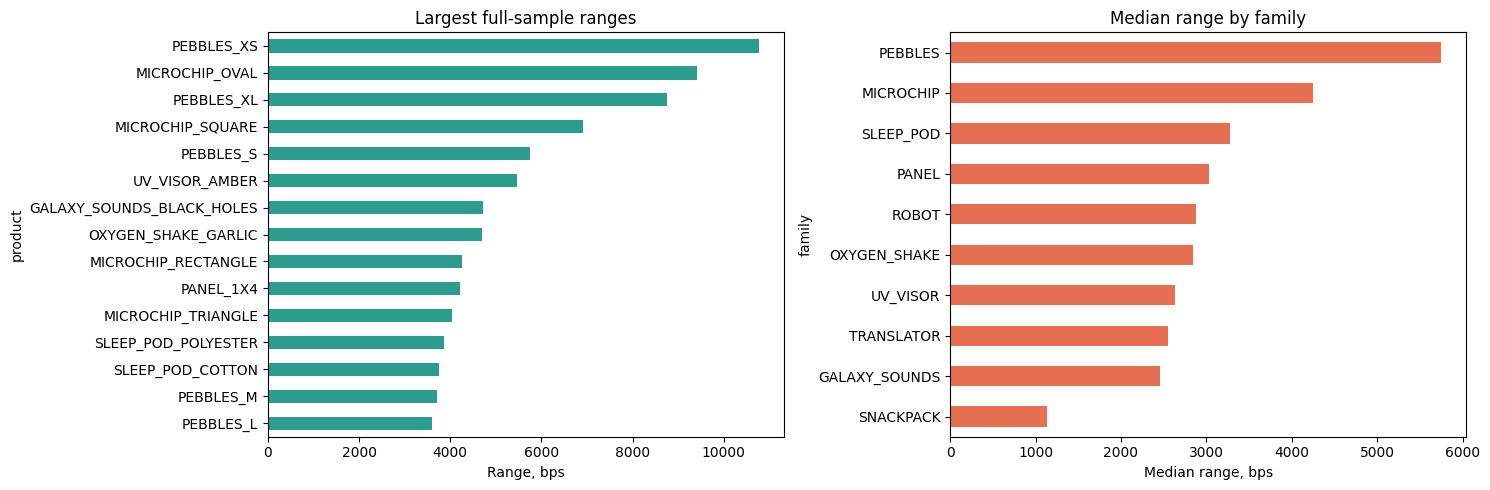

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
product_summary.head(15)["range_bps"].sort_values().plot(kind="barh", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Largest full-sample ranges")
axes[0].set_xlabel("Range, bps")

family_summary["median_range_bps"].sort_values().plot(kind="barh", ax=axes[1], color="#e76f51")
axes[1].set_title("Median range by family")
axes[1].set_xlabel("Median range, bps")
plt.tight_layout()

## Price Paths By Family

Pick any family to inspect whether members are moving together, diverging, or drifting with obvious leaders/laggards.

['GALAXY_SOUNDS', 'MICROCHIP', 'OXYGEN_SHAKE', 'PANEL', 'PEBBLES', 'ROBOT', 'SLEEP_POD', 'SNACKPACK', 'TRANSLATOR', 'UV_VISOR']


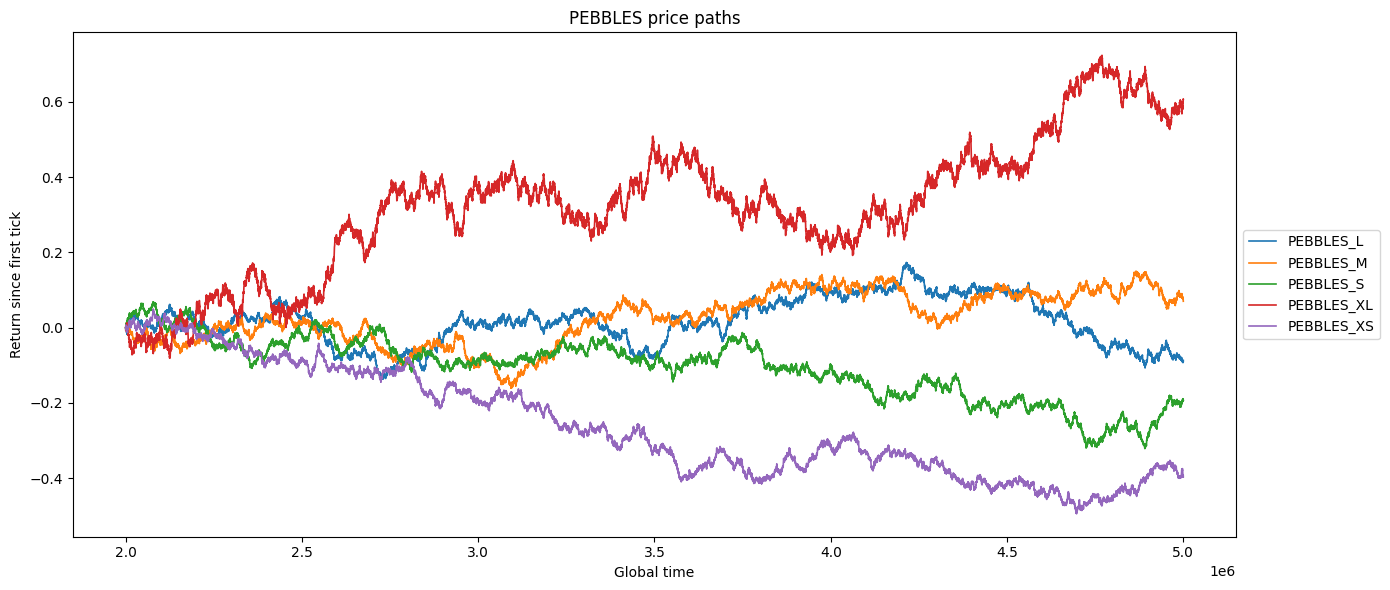

In [7]:
def plot_family(family: str, normalize=True):
    subset = prices[prices["family"].eq(family)].copy()
    if subset.empty:
        raise ValueError(f"Unknown family: {family}")
    pivot = subset.pivot_table(index="global_time", columns="product", values="mid_price")
    if normalize:
        pivot = pivot / pivot.iloc[0] - 1
        ylabel = "Return since first tick"
    else:
        ylabel = "Mid price"
    ax = pivot.plot(figsize=(14, 6), lw=1.2)
    ax.set_title(f"{family} price paths")
    ax.set_xlabel("Global time")
    ax.set_ylabel(ylabel)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()

families = sorted(prices["family"].unique())
print(families)
plot_family("PEBBLES")

## Signal IC Scan

This section computes simple information coefficients: correlation between a feature observed now and a future mid-price return. It reports train and validation scores separately.

Interpretation tips:

- positive IC means high feature values tend to precede positive returns
- negative IC means high feature values tend to precede negative returns
- validation matters more than train
- large ICs on tiny sample counts are suspicious

In [8]:
def safe_corr(x, y, min_n=500):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < min_n:
        return np.nan, mask.sum()
    xs = x[mask]
    ys = y[mask]
    if np.nanstd(xs) == 0 or np.nanstd(ys) == 0:
        return np.nan, mask.sum()
    return float(np.corrcoef(xs, ys)[0, 1]), int(mask.sum())


def ic_scan(df, features=feature_cols, horizons=HORIZONS, days=None, by_product=True):
    use = df if days is None else df[df["day"].isin(days)]
    rows = []
    groups = use.groupby("product") if by_product else [("ALL", use)]
    for product, g in groups:
        for feature in features:
            x = g[feature].to_numpy(dtype=float)
            for h in horizons:
                y = g[f"fwd_ret_{h}"].to_numpy(dtype=float)
                corr, n = safe_corr(x, y)
                rows.append({"product": product, "feature": feature, "horizon": h, "ic": corr, "n": n})
    return pd.DataFrame(rows)

train_ic = ic_scan(prices, days=TRAIN_DAYS)
valid_ic = ic_scan(prices, days=VALID_DAYS)

signal_summary = (
    train_ic.rename(columns={"ic": "train_ic", "n": "train_n"})
    .merge(valid_ic.rename(columns={"ic": "valid_ic", "n": "valid_n"}), on=["product", "feature", "horizon"], how="outer")
)
signal_summary["same_sign"] = np.sign(signal_summary["train_ic"]) == np.sign(signal_summary["valid_ic"])
signal_summary["score"] = signal_summary["valid_ic"].abs() * signal_summary["same_sign"].astype(float)

# Show candidates that had a direction in train and repeated in validation.
top_signals = (
    signal_summary
    .query("same_sign and train_n >= 500 and valid_n >= 500")
    .assign(abs_valid_ic=lambda d: d["valid_ic"].abs())
    .sort_values(["abs_valid_ic", "train_ic"], ascending=[False, False])
)
display(top_signals.head(30))

# Feature-level aggregate, useful for seeing broad effects.
feature_level = (
    signal_summary.groupby(["feature", "horizon"])
    .agg(
        mean_train_ic=("train_ic", "mean"),
        mean_valid_ic=("valid_ic", "mean"),
        median_train_ic=("train_ic", "median"),
        median_valid_ic=("valid_ic", "median"),
        same_sign_rate=("same_sign", "mean"),
    )
    .sort_values("mean_valid_ic", key=lambda s: s.abs(), ascending=False)
)
display(feature_level.head(30))

,product,feature,horizon,train_ic,train_n,valid_ic,valid_n,same_sign,score,abs_valid_ic
1324,ROBOT_DISHES,ret_1,1,-0.0017,19996,-0.2894,9998,True,0.2894,0.2894
1207,PEBBLES_XL,family_rel_z_500,100,-0.1344,19701,-0.1559,9900,True,0.1559,0.1559
323,MICROCHIP_OVAL,family_rel_z_500,100,-0.0522,19701,-0.1474,9900,True,0.1474,0.1474
1935,SNACKPACK_RASPBERRY,family_rel_z_500,100,-0.0088,19701,-0.1409,9900,True,0.1409,0.1409
1888,SNACKPACK_PISTACHIO,imbalance_3,1,-0.1264,19998,-0.1389,9999,True,0.1389,0.1389
1884,SNACKPACK_PISTACHIO,imbalance_1,1,0.1292,19998,0.1387,9999,True,0.1387,0.1387
1892,SNACKPACK_PISTACHIO,microprice_edge_bps,1,0.1287,19998,0.1376,9999,True,0.1376,0.1376
1832,SNACKPACK_CHOCOLATE,imbalance_1,1,0.1091,19998,0.1344,9999,True,0.1344,0.1344
1840,SNACKPACK_CHOCOLATE,microprice_edge_bps,1,0.1083,19998,0.1334,9999,True,0.1334,0.1334
1836,SNACKPACK_CHOCOLATE,imbalance_3,1,-0.1043,19998,-0.1322,9999,True,0.1322,0.1322


,,mean_train_ic,mean_valid_ic,median_train_ic,median_valid_ic,same_sign_rate
feature,horizon,,,,,
imbalance_3,1,-0.0472,-0.0496,-0.0434,-0.0443,1.0000
imbalance_1,1,0.0443,0.0484,0.0415,0.0441,0.9800
microprice_edge_bps,1,0.0416,0.0460,0.0386,0.0406,0.9600
family_rel_z_500,100,-0.0190,-0.0309,-0.0196,-0.0217,0.5000
imbalance_1,5,0.0213,0.0233,0.0179,0.0227,0.9400
imbalance_3,5,-0.0215,-0.0225,-0.0201,-0.0222,0.9200
microprice_edge_bps,5,0.0199,0.0224,0.0171,0.0222,0.8600
family_rel_z_500,20,-0.0066,-0.0183,-0.0158,-0.0105,0.4800
ret_1,1,-0.0125,-0.0170,-0.0047,-0.0042,0.7800


## Simple Directional Backtest

This is a deliberately rough signal sanity check. It normalizes a feature per product/day, clips extreme z-scores, and measures `position * future_return`. It ignores inventory limits, fills, queue priority, and fees, so use it to rank hypotheses rather than to estimate final PnL.

In [9]:
def zscore_by_product_day(df, col, cap=3.0):
    g = df.groupby(["product", "day"])[col]
    z = (df[col] - g.transform("mean")) / g.transform("std").replace(0, np.nan)
    return z.clip(-cap, cap)


def rough_signal_backtest(df, features=feature_cols, horizons=HORIZONS, days=None):
    use = df if days is None else df[df["day"].isin(days)]
    rows = []
    for feature in features:
        pos = zscore_by_product_day(use, feature).fillna(0)
        for h in horizons:
            pnl = pos * use[f"fwd_ret_{h}"]
            pnl = pnl.replace([np.inf, -np.inf], np.nan).dropna()
            if len(pnl) < 1000 or pnl.std() == 0:
                continue
            rows.append({
                "feature": feature,
                "horizon": h,
                "n": len(pnl),
                "mean_bps": pnl.mean() * 1e4,
                "std_bps": pnl.std() * 1e4,
                "t_stat": pnl.mean() / pnl.std() * np.sqrt(len(pnl)),
                "hit_rate": (pnl > 0).mean(),
            })
    return pd.DataFrame(rows).sort_values("t_stat", key=lambda s: s.abs(), ascending=False)

bt_train = rough_signal_backtest(prices, days=TRAIN_DAYS)
bt_valid = rough_signal_backtest(prices, days=VALID_DAYS)

display(Markdown("### Train"))
display(bt_train.head(20))
display(Markdown("### Validation"))
display(bt_valid.head(20))

### Train

,feature,horizon,n,mean_bps,std_bps,t_stat,hit_rate
20,imbalance_3,1,999900,-0.2614,6.0752,-43.0331,0.4734
16,imbalance_1,1,999900,0.2635,7.6183,34.5826,0.4828
24,microprice_edge_bps,1,999900,0.2477,7.4850,33.0938,0.4822
51,family_rel_z_500,100,990000,-3.3376,113.0993,-29.3626,0.4884
21,imbalance_3,5,999500,-0.2715,13.1407,-20.6592,0.4860
17,imbalance_1,5,999500,0.2873,16.6806,17.2194,0.4932
25,microprice_edge_bps,5,999500,0.2703,16.4201,16.4545,0.4919
50,family_rel_z_500,20,998000,-0.6306,50.4773,-12.4810,0.4888
22,imbalance_3,20,998000,-0.2801,26.3679,-10.6115,0.4909
0,ret_1,1,999900,-0.1129,11.5627,-9.7615,0.4750


### Validation

,feature,horizon,n,mean_bps,std_bps,t_stat,hit_rate
20,imbalance_3,1,499950,-0.2905,6.5179,-31.5143,0.4682
16,imbalance_1,1,499950,0.3007,8.5781,24.7857,0.4765
24,microprice_edge_bps,1,499950,0.2835,8.5056,23.5658,0.4766
51,family_rel_z_500,100,495000,-3.6314,111.0999,-22.9964,0.4878
21,imbalance_3,5,499750,-0.2845,13.7176,-14.6609,0.4818
50,family_rel_z_500,20,499000,-1.0319,50.9601,-14.3035,0.4851
0,ret_1,1,499950,-0.2269,12.9177,-12.4190,0.4700
17,imbalance_1,5,499750,0.3140,18.7321,11.8518,0.4858
25,microprice_edge_bps,5,499750,0.3031,18.6570,11.4855,0.4851
10,ret_20,20,499000,-0.8206,51.0537,-11.3547,0.4864


## Within-Family Pair Scanner

Many products look like variants of the same economic object. This scanner fits a static hedge ratio inside each family on train days, then asks whether the residual spread mean-reverts in validation.

A negative `valid_ic` means: when the spread z-score is high, the spread tends to fall over the next horizon, which is the usual mean-reversion direction.

In [10]:
def pair_scan(df, families=None, horizon=20, train_days=TRAIN_DAYS, valid_days=VALID_DAYS, rolling_window=500):
    families = families or sorted(df["family"].unique())
    rows = []

    for family in families:
        products = sorted(df.loc[df["family"].eq(family), "product"].unique())
        if len(products) < 2:
            continue

        wide = (
            df[df["product"].isin(products)]
            .pivot_table(index=["day", "timestamp"], columns="product", values="log_mid")
            .sort_index()
        )
        train_mask = wide.index.get_level_values("day").isin(train_days)
        valid_mask = wide.index.get_level_values("day").isin(valid_days)

        for a, b in combinations(products, 2):
            pair = wide[[a, b]].dropna()
            pair_train = pair[pair.index.get_level_values("day").isin(train_days)]
            pair_valid = pair[pair.index.get_level_values("day").isin(valid_days)]
            if len(pair_train) < rolling_window or len(pair_valid) < rolling_window:
                continue

            x = pair_train[b].to_numpy()
            y = pair_train[a].to_numpy()
            beta = np.cov(x, y)[0, 1] / np.var(x) if np.var(x) else np.nan
            if not np.isfinite(beta):
                continue

            for split_name, pair_split in [("train", pair_train), ("valid", pair_valid)]:
                resid = pair_split[a] - beta * pair_split[b]
                z = (resid - resid.rolling(rolling_window, min_periods=100).mean()) / resid.rolling(rolling_window, min_periods=100).std()
                future_spread_change = resid.shift(-horizon) - resid
                ic, n = safe_corr(z.to_numpy(), future_spread_change.to_numpy(), min_n=500)
                rows.append({
                    "family": family,
                    "a": a,
                    "b": b,
                    "split": split_name,
                    "horizon": horizon,
                    "beta_a_vs_b": beta,
                    "ic_z_vs_spread_change": ic,
                    "mean_reversion_score": -ic if np.isfinite(ic) else np.nan,
                    "n": n,
                })

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.pivot_table(
        index=["family", "a", "b", "horizon", "beta_a_vs_b"],
        columns="split",
        values=["ic_z_vs_spread_change", "mean_reversion_score", "n"],
        aggfunc="first",
    ).reset_index()

pairs_20 = pair_scan(prices, horizon=20)
# Flatten the MultiIndex columns from pivot_table.
pairs_20.columns = ["_".join([str(x) for x in col if x]) if isinstance(col, tuple) else col for col in pairs_20.columns]

pair_candidates = (
    pairs_20
    .assign(valid_score=lambda d: d["mean_reversion_score_valid"])
    .query("mean_reversion_score_train > 0 and mean_reversion_score_valid > 0")
    .sort_values("valid_score", ascending=False)
)
display(pair_candidates.head(30))

,family,a,b,horizon,beta_a_vs_b,ic_z_vs_spread_change_train,ic_z_vs_spread_change_valid,mean_reversion_score_train,mean_reversion_score_valid,n_train,n_valid,valid_score
49,PEBBLES,PEBBLES_XL,PEBBLES_XS,20,-0.5551,-0.0383,-0.1456,0.0383,0.1456,19881,9881,0.1456
38,PANEL,PANEL_2X2,PANEL_4X4,20,-0.7791,-0.0244,-0.1083,0.0244,0.1083,19881,9881,0.1083
44,PEBBLES,PEBBLES_M,PEBBLES_S,20,-0.2280,-0.0506,-0.1042,0.0506,0.1042,19881,9881,0.1042
76,SNACKPACK,SNACKPACK_PISTACHIO,SNACKPACK_VANILLA,20,-0.0882,-0.0205,-0.0940,0.0205,0.0940,19881,9881,0.0940
75,SNACKPACK,SNACKPACK_PISTACHIO,SNACKPACK_STRAWBERRY,20,-0.1631,-0.0236,-0.0917,0.0236,0.0917,19881,9881,0.0917
78,SNACKPACK,SNACKPACK_RASPBERRY,SNACKPACK_VANILLA,20,0.0147,-0.0266,-0.0704,0.0266,0.0704,19881,9881,0.0704
77,SNACKPACK,SNACKPACK_RASPBERRY,SNACKPACK_STRAWBERRY,20,-0.1933,-0.0299,-0.0699,0.0299,0.0699,19881,9881,0.0699
46,PEBBLES,PEBBLES_M,PEBBLES_XS,20,-0.2083,-0.0577,-0.0696,0.0577,0.0696,19881,9881,0.0696
67,SLEEP_POD,SLEEP_POD_NYLON,SLEEP_POD_POLYESTER,20,-0.2217,-0.0089,-0.0696,0.0089,0.0696,19881,9881,0.0696
11,MICROCHIP,MICROCHIP_CIRCLE,MICROCHIP_RECTANGLE,20,0.2438,-0.0303,-0.0634,0.0303,0.0634,19881,9881,0.0634


## Trade Print Markouts

This asks whether public trades above/below contemporaneous mid contain directional information. The side is inferred only from price relative to mid, so it is an approximation:

- trade above mid: likely buyer-initiated
- trade below mid: likely seller-initiated
- positive directional markout: price moved in the inferred aggressor direction after the print

In [11]:
def trade_markouts(prices, trades, horizons=HORIZONS):
    cols = ["day", "timestamp", "product", "mid_price"] + [f"fwd_ret_{h}" for h in horizons]
    tape = trades.merge(prices[cols], on=["day", "timestamp", "product"], how="left")
    tape = tape.dropna(subset=["mid_price"])
    tape["trade_edge_bps"] = (tape["price"] / tape["mid_price"] - 1) * 1e4
    tape["side_hint"] = np.sign(tape["trade_edge_bps"])
    tape = tape[tape["side_hint"].ne(0)].copy()
    for h in horizons:
        tape[f"directional_markout_{h}_bps"] = tape["side_hint"] * tape[f"fwd_ret_{h}"] * 1e4
    return tape

tape = trade_markouts(prices, trades_raw)

markout_summary = []
for h in HORIZONS:
    tmp = (
        tape.groupby("product")[f"directional_markout_{h}_bps"]
        .agg(["count", "mean", "median", "std"])
        .rename(columns={"mean": f"mean_markout_{h}_bps", "median": f"median_markout_{h}_bps", "std": f"std_markout_{h}_bps"})
    )
    tmp[f"t_stat_{h}"] = tmp[f"mean_markout_{h}_bps"] / tmp[f"std_markout_{h}_bps"] * np.sqrt(tmp["count"])
    tmp["horizon"] = h
    markout_summary.append(tmp.reset_index())
markout_summary = pd.concat(markout_summary, ignore_index=True)

display(markout_summary.sort_values("t_stat_20", key=lambda s: s.abs() if s.name == "t_stat_20" else s, ascending=False).head(20) if "t_stat_20" in markout_summary else markout_summary.head())

overall_markouts = tape[[f"directional_markout_{h}_bps" for h in HORIZONS]].agg(["count", "mean", "median", "std"]).T
overall_markouts["t_stat"] = overall_markouts["mean"] / overall_markouts["std"] * np.sqrt(overall_markouts["count"])
display(overall_markouts)

,product,count,mean_markout_1_bps,median_markout_1_bps,std_markout_1_bps,t_stat_1,horizon,mean_markout_5_bps,median_markout_5_bps,std_markout_5_bps,t_stat_5,mean_markout_20_bps,median_markout_20_bps,std_markout_20_bps,t_stat_20,mean_markout_100_bps,median_markout_100_bps,std_markout_100_bps,t_stat_100
134,SLEEP_POD_SUEDE,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,-3.5361,-4.0091,43.3559,-2.2036,NaN,NaN,NaN,NaN
137,SNACKPACK_RASPBERRY,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,-2.4195,-4.8860,33.2028,-1.9688,NaN,NaN,NaN,NaN
110,OXYGEN_SHAKE_CHOCOLATE,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,2.9914,1.0709,43.2244,1.8698,NaN,NaN,NaN,NaN
138,SNACKPACK_STRAWBERRY,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,1.9659,2.3662,31.5868,1.6816,NaN,NaN,NaN,NaN
109,MICROCHIP_TRIANGLE,568,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,-4.7580,-6.9906,67.7989,-1.6725,NaN,NaN,NaN,NaN
125,ROBOT_DISHES,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,2.9390,-0.0000,48.2113,1.6471,NaN,NaN,NaN,NaN
130,SLEEP_POD_COTTON,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,-2.5590,-1.9851,43.2026,-1.6004,NaN,NaN,NaN,NaN
140,TRANSLATOR_ASTRO_BLACK,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,-2.5550,-2.7828,44.4320,-1.5536,NaN,NaN,NaN,NaN
148,UV_VISOR_RED,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,2.3865,1.8750,42.7266,1.5091,NaN,NaN,NaN,NaN
136,SNACKPACK_PISTACHIO,730,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,1.2134,1.0649,22.8960,1.4319,NaN,NaN,NaN,NaN


,count,mean,median,std,t_stat
directional_markout_1_bps,"35,385.0000",0.0018,0.0000,11.4157,0.0294
directional_markout_5_bps,"35,345.0000",0.0402,0.0000,25.1163,0.3011
directional_markout_20_bps,"35,250.0000",-0.1704,0.0000,49.5391,-0.6459
directional_markout_100_bps,"34,880.0000",0.4608,0.9077,109.6405,0.7849


## Candidate Notebook Conclusions

Run the cells above, then use this checklist to decide what deserves deeper strategy work:

1. A feature should have the same sign in train and day-4 validation.
2. A feature should make intuitive market-structure sense, not just rank high once.
3. Relative-value signals are stronger candidates when multiple pairs inside the same family show the same effect.
4. Trade-print markouts are most useful when the effect survives by product and horizon, not only in the full tape.
5. Before productionizing anything, rerun with realistic fills, position limits, inventory penalties, and transaction costs.

Good next notebook extensions:

- walk-forward validation by day or intraday block
- queue-aware fill model using bid/ask depth
- family-neutral portfolio construction
- holding-period overlap correction for t-stats
- parameter sweep for rolling windows and horizons